# Evaluation and Threshold Simulation

The model is evaluated as a customer prioritization tool. The main question is not only whether the model predicts `yes` or `no`, but which customers should be contacted first.

The main evaluation approach is top-k targeting simulation. Fixed probability threshold simulation is included as secondary support.


## 1. Setup

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

REPORTS_DIR = PROJECT_ROOT / "reports"
PREDICTIONS_DIR = PROJECT_ROOT / "data" / "predictions"

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

print("Project root:", PROJECT_ROOT)
print("Reports path exists:", REPORTS_DIR.exists())
print("Predictions path exists:", PREDICTIONS_DIR.exists())

Project root: /Users/morenomusadat/Downloads/bank-campaign-targeting-system
Reports path exists: True
Predictions path exists: True


## 2. Load Evaluation Outputs

In [2]:
validation_topk = pd.read_csv(REPORTS_DIR / "threshold_simulation_validation.csv")
test_topk = pd.read_csv(REPORTS_DIR / "threshold_simulation_test.csv")

validation_fixed = pd.read_csv(REPORTS_DIR / "fixed_threshold_simulation_validation.csv")
test_fixed = pd.read_csv(REPORTS_DIR / "fixed_threshold_simulation_test.csv")

selected_policy = pd.read_csv(REPORTS_DIR / "selected_threshold_policy.csv")
customer_scores = pd.read_csv(PREDICTIONS_DIR / "customer_scores.csv")

display(validation_topk)
display(selected_policy)
display(test_topk.head())

,split,method,contact_rate,targeted_customers,total_customers,captured_subscribers,total_subscribers,false_positives,missed_subscribers,precision_at_k,capture_rate_at_k,lift_at_k,baseline_subscription_rate,score_cutoff
0,validation,top_k,0.05,197,3940,127,460,70,333,0.644670,0.276087,5.521739,0.116751,0.867407
1,validation,top_k,0.10,394,3940,200,460,194,260,0.507614,0.434783,4.347826,0.116751,0.794397
2,validation,top_k,0.15,591,3940,265,460,326,195,0.448393,0.576087,3.840580,0.116751,0.628929
3,validation,top_k,0.20,788,3940,296,460,492,164,0.375635,0.643478,3.217391,0.116751,0.497749
4,validation,top_k,0.25,985,3940,314,460,671,146,0.318782,0.682609,2.730435,0.116751,0.432348
5,validation,top_k,0.30,1182,3940,331,460,851,129,0.280034,0.719565,2.398551,0.116751,0.399555


,selected_contact_rate,selection_rule,validation_targeted_customers,validation_captured_subscribers,validation_precision_at_k,validation_capture_rate_at_k,validation_lift_at_k,validation_score_cutoff,test_targeted_customers,test_captured_subscribers,test_precision_at_k,test_capture_rate_at_k,test_lift_at_k,test_score_cutoff
0,0.2,smallest_contact_rate_with_capture_rate_at_lea...,788,296,0.375635,0.643478,3.217391,0.497749,789,298,0.377693,0.647826,3.235846,0.503227


,split,method,contact_rate,targeted_customers,total_customers,captured_subscribers,total_subscribers,false_positives,missed_subscribers,precision_at_k,capture_rate_at_k,lift_at_k,baseline_subscription_rate,score_cutoff
0,test,top_k,0.05,198,3941,141,460,57,319,0.712121,0.306522,6.101021,0.116722,0.856111
1,test,top_k,0.10,395,3941,210,460,185,250,0.531646,0.456522,4.554816,0.116722,0.781032
2,test,top_k,0.15,592,3941,272,460,320,188,0.459459,0.591304,3.936369,0.116722,0.628298
3,test,top_k,0.20,789,3941,298,460,491,162,0.377693,0.647826,3.235846,0.116722,0.503227
4,test,top_k,0.25,986,3941,319,460,667,141,0.323529,0.693478,2.771803,0.116722,0.432908


## 3. Validation Top-k Targeting Simulation

The validation set is used to choose the targeting policy. This avoids tuning the business cutoff directly on the test set.

Important metrics:

- `precision_at_k`: subscription rate among selected customers.
- `capture_rate_at_k`: share of all subscribers captured.
- `lift_at_k`: how much better the selected group is compared with random targeting.


In [3]:
display(
    validation_topk[
        [
            "contact_rate",
            "targeted_customers",
            "captured_subscribers",
            "precision_at_k",
            "capture_rate_at_k",
            "lift_at_k",
            "score_cutoff",
        ]
    ]
)

,contact_rate,targeted_customers,captured_subscribers,precision_at_k,capture_rate_at_k,lift_at_k,score_cutoff
0,0.05,197,127,0.644670,0.276087,5.521739,0.867407
1,0.10,394,200,0.507614,0.434783,4.347826,0.794397
2,0.15,591,265,0.448393,0.576087,3.840580,0.628929
3,0.20,788,296,0.375635,0.643478,3.217391,0.497749
4,0.25,985,314,0.318782,0.682609,2.730435,0.432348
5,0.30,1182,331,0.280034,0.719565,2.398551,0.399555


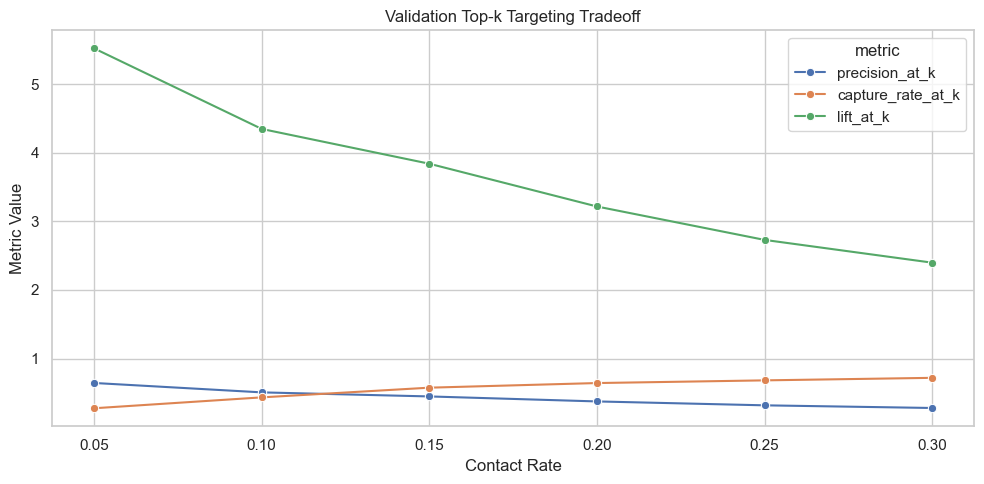

In [4]:
plot_data = validation_topk.melt(
    id_vars=["contact_rate"],
    value_vars=["precision_at_k", "capture_rate_at_k", "lift_at_k"],
    var_name="metric",
    value_name="value",
)

plt.figure(figsize=(10, 5))
sns.lineplot(data=plot_data, x="contact_rate", y="value", hue="metric", marker="o")
plt.title("Validation Top-k Targeting Tradeoff")
plt.xlabel("Contact Rate")
plt.ylabel("Metric Value")
plt.tight_layout()
plt.show()

**Interpretation:**

The validation results show the expected targeting tradeoff. Smaller contact groups have higher precision and lift, but they capture fewer subscribers. For example, top 5% targeting has **64.47% precision** and **5.52x lift**, but captures only **27.61%** of subscribers. Top 30% captures more subscribers at **71.96%**, but precision drops to **28.00%** and lift drops to **2.40x**.

## 4. Selected Policy

The selected policy is chosen from validation results, then applied to the test set.

In [5]:
display(selected_policy.T)

,0
selected_contact_rate,0.2
selection_rule,smallest_contact_rate_with_capture_rate_at_lea...
validation_targeted_customers,788
validation_captured_subscribers,296
validation_precision_at_k,0.375635
validation_capture_rate_at_k,0.643478
validation_lift_at_k,3.217391
validation_score_cutoff,0.497749
test_targeted_customers,789
test_captured_subscribers,298


**Interpretation:**

This selected a **20% contact rate**. On validation, it targets **788** customers, captures **296 subscribers**, reaches **37.56% precision**, captures **64.35%** of all subscribers, and has **3.22x lift**. When applied to the test set, it remains stable: **789 targeted customers**, **298 captured subscribers**, **37.77% precision**, **64.78% capture rate**, and **3.24x lift**.

## 5. Final Test Top-k Result

The test set gives the final estimate for the selected model and selected targeting policy.


In [6]:
selected_contact_rate = selected_policy.loc[0, "selected_contact_rate"]

test_selected_row = test_topk[test_topk["contact_rate"].round(4) == round(selected_contact_rate, 4)]

display(test_selected_row)

display(
    test_topk[
        [
            "contact_rate",
            "targeted_customers",
            "captured_subscribers",
            "precision_at_k",
            "capture_rate_at_k",
            "lift_at_k",
            "score_cutoff",
        ]
    ]
)

,split,method,contact_rate,targeted_customers,total_customers,captured_subscribers,total_subscribers,false_positives,missed_subscribers,precision_at_k,capture_rate_at_k,lift_at_k,baseline_subscription_rate,score_cutoff
3,test,top_k,0.2,789,3941,298,460,491,162,0.377693,0.647826,3.235846,0.116722,0.503227


,contact_rate,targeted_customers,captured_subscribers,precision_at_k,capture_rate_at_k,lift_at_k,score_cutoff
0,0.05,198,141,0.712121,0.306522,6.101021,0.856111
1,0.10,395,210,0.531646,0.456522,4.554816,0.781032
2,0.15,592,272,0.459459,0.591304,3.936369,0.628298
3,0.20,789,298,0.377693,0.647826,3.235846,0.503227
4,0.25,986,319,0.323529,0.693478,2.771803,0.432908
5,0.30,1183,329,0.278107,0.715217,2.382647,0.396724


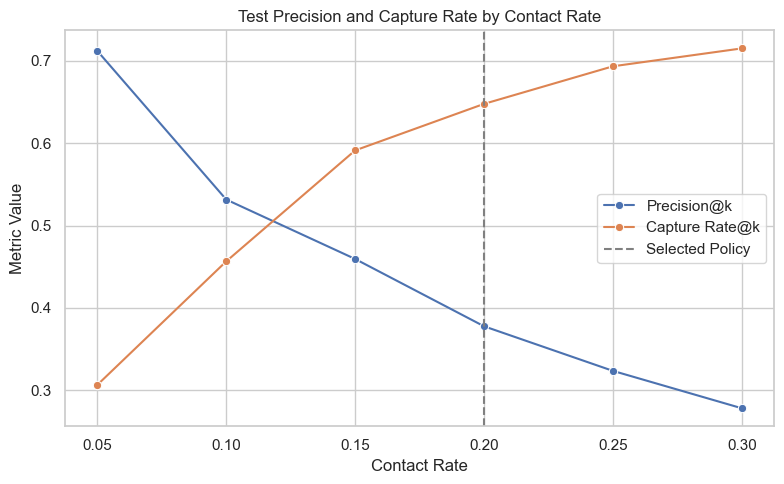

In [7]:
plt.figure(figsize=(8, 5))
sns.lineplot(data=test_topk, x="contact_rate", y="precision_at_k", marker="o", label="Precision@k")
sns.lineplot(data=test_topk, x="contact_rate", y="capture_rate_at_k", marker="o", label="Capture Rate@k")
plt.axvline(selected_contact_rate, linestyle="--", color="gray", label="Selected Policy")
plt.title("Test Precision and Capture Rate by Contact Rate")
plt.xlabel("Contact Rate")
plt.ylabel("Metric Value")
plt.legend()
plt.tight_layout()
plt.show()

**Interpretation:**

The graph above shows the tradeoff between precision@k and capture rate@k. Precision decreases as the contact rate increases because the campaign starts including less certain customers. Capture rate increases because more total subscribers are reached when more customers are contacted. The top 5% gives the highest precision, 71.21%, but only captures 30.65% of all subscribers. 
<br><br>
Top 10% improves capture to 45.65%, while top 15% reaches 59.13%, which is still slightly below the 60% capture rule. The top 20% policy captures 64.78% of subscribers with 37.77% precision, making it the first option that satisfies the capture requirement while still maintaining a much better-than-random subscriber concentration

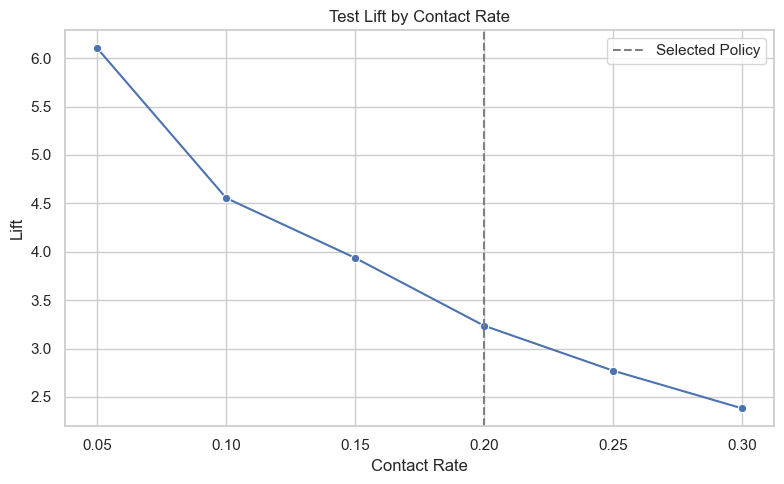

In [8]:
plt.figure(figsize=(8, 5))
sns.lineplot(data=test_topk, x="contact_rate", y="lift_at_k", marker="o")
plt.axvline(selected_contact_rate, linestyle="--", color="gray", label="Selected Policy")
plt.title("Test Lift by Contact Rate")
plt.xlabel("Contact Rate")
plt.ylabel("Lift")
plt.legend()
plt.tight_layout()
plt.show()

**Interpretation:**

The graph above  shows that lift decreases as the contact rate increases. This is expected because the model ranks customers from highest to lowest predicted likelihood of subscribing. At the top 5%, the contacted group is highly concentrated with actual subscribers, producing the highest lift of around 6.10x. 
<br><br>
However, as the campaign expands to the top 10%, 15%, 20%, and beyond, lower-ranked customers are gradually included, so the average quality of the contacted group decreases and lift falls. The dashed vertical line marks the selected policy at the top 20% contact rate, where the model still achieves a strong lift of around 3.22x.

Overall, this result supports the selected recommendation. The model does not need to contact the full customer base. Instead, it can focus on the highest-scored 20% of customers while still capturing almost 65% of all actual subscribers in the test set. However, this should be interpreted as a targeting-efficiency result, not a profit result, because campaign cost, revenue, and customer lifetime value are not available.

## 6. Fixed Threshold Simulation

This is a secondary analysis that will be useful for understanding probability cutoffs, but top-k targeting is more directly tied to campaign capacity.


In [9]:
display(
    test_fixed[
        [
            "threshold",
            "contact_rate",
            "targeted_customers",
            "captured_subscribers",
            "precision",
            "capture_rate",
            "lift",
        ]
    ]
)

,threshold,contact_rate,targeted_customers,captured_subscribers,precision,capture_rate,lift
0,0.1,0.991373,3907,460,0.117737,1.000000,1.008702
1,0.2,0.831261,3276,438,0.133700,0.952174,1.145457
2,0.3,0.509515,2008,380,0.189243,0.826087,1.621319
3,0.4,0.294088,1159,327,0.282140,0.710870,2.417202
4,0.5,0.201725,795,299,0.376101,0.650000,3.222201
5,0.6,0.157320,620,279,0.450000,0.606522,3.855326
6,0.7,0.132707,523,252,0.481836,0.547826,4.128074
7,0.8,0.086273,340,190,0.558824,0.413043,4.787660
8,0.9,0.034509,136,106,0.779412,0.230435,6.677526


**Interpretation:**

The fixed-threshold table shows how model behavior changes when using probability cutoffs instead of top-k contact rates. At threshold 0.5, the model contacts 795 customers, captures 299 subscribers, achieves 37.61% precision, 65.00% capture rate, and 3.22x lift. This is very close to the top 20% policy because the selected top-20% score cutoff is around 0.503 on the test set.
<br><br>
Higher thresholds improve precision but reduce capture. For example, threshold 0.9 gives 77.94% precision and 6.68x lift, but captures only 23.04% of subscribers. Lower thresholds capture more subscribers, but they contact too many customers and lose efficiency.

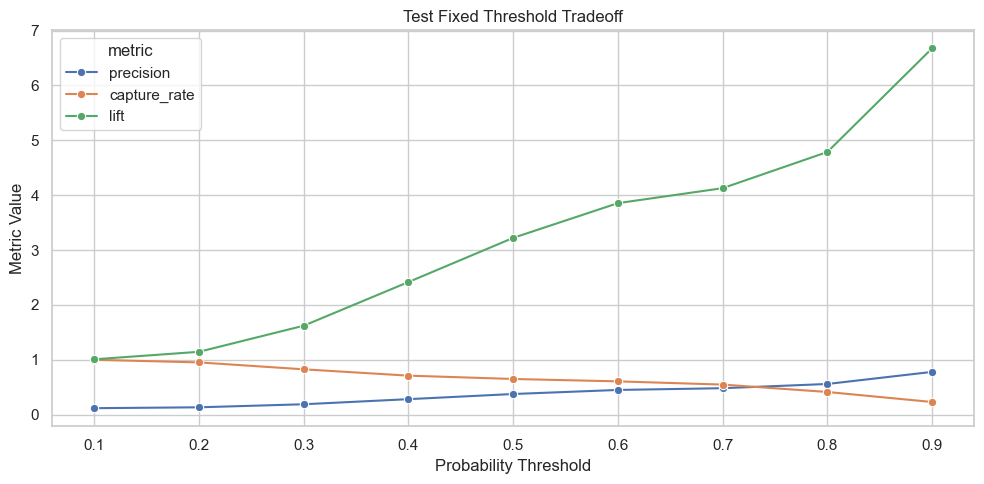

In [10]:
fixed_plot_data = test_fixed.melt(
    id_vars=["threshold"],
    value_vars=["precision", "capture_rate", "lift"],
    var_name="metric",
    value_name="value",
)

plt.figure(figsize=(10, 5))
sns.lineplot(data=fixed_plot_data, x="threshold", y="value", hue="metric", marker="o")
plt.title("Test Fixed Threshold Tradeoff")
plt.xlabel("Probability Threshold")
plt.ylabel("Metric Value")
plt.tight_layout()
plt.show()

## 7. Customer Score Table

In [11]:
display(customer_scores.head(20))

print("Rows:", len(customer_scores))
print("Columns:", len(customer_scores.columns))

,customer_id,split,actual_subscription,predicted_probability,predicted_label_0_5,score_rank,score_percentile,recommended_selected_top_20,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,was_previously_contacted,pdays_clean,y_binary,recommended_top_5,recommended_top_10,recommended_top_15,recommended_top_20,recommended_top_25,recommended_top_30
0,test_003812,test,1,0.979760,1,1,1.000000,True,60,admin.,married,university.degree,no,no,no,cellular,jul,fri,1,2,success,-1.7,94.215,-40.3,0.861,4991.6,1,6,1,True,True,True,True,True,True
1,test_000117,test,1,0.978908,1,2,0.999746,True,80,housemaid,married,basic.4y,no,yes,yes,cellular,apr,tue,1,1,success,-1.8,93.749,-34.6,0.644,5008.7,1,12,1,True,True,True,True,True,True
2,test_003151,test,1,0.977857,1,3,0.999493,True,80,retired,divorced,basic.4y,no,yes,yes,cellular,apr,thu,1,2,success,-1.8,93.749,-34.6,0.644,5008.7,1,10,1,True,True,True,True,True,True
3,test_002892,test,1,0.973178,1,4,0.999239,True,36,admin.,married,university.degree,no,yes,yes,cellular,may,thu,1,2,success,-1.8,93.876,-40.0,0.699,5008.7,1,6,1,True,True,True,True,True,True
4,test_002118,test,1,0.972595,1,5,0.998985,True,36,admin.,single,university.degree,no,no,no,cellular,jun,wed,1,1,success,-1.7,94.055,-39.8,0.739,4991.6,1,7,1,True,True,True,True,True,True
5,test_003386,test,1,0.972342,1,6,0.998731,True,34,admin.,married,university.degree,no,no,no,cellular,jun,wed,1,2,success,-1.7,94.055,-39.8,0.715,4991.6,1,3,1,True,True,True,True,True,True
6,test_002420,test,1,0.972178,1,7,0.998478,True,24,student,single,professional.course,no,no,no,cellular,jul,wed,2,3,success,-1.7,94.215,-40.3,0.896,4991.6,1,6,1,True,True,True,True,True,True
7,test_000264,test,1,0.972041,1,8,0.998224,True,48,admin.,divorced,high.school,no,no,no,cellular,jun,wed,1,1,success,-1.7,94.055,-39.8,0.704,4991.6,1,6,1,True,True,True,True,True,True
8,test_002055,test,1,0.971798,1,9,0.997970,True,26,student,single,university.degree,no,no,no,cellular,nov,fri,1,1,success,-3.4,92.649,-30.1,0.714,5017.5,1,7,1,True,True,True,True,True,True
9,test_002710,test,1,0.971772,1,10,0.997716,True,55,unemployed,divorced,university.degree,no,no,no,cellular,mar,tue,3,3,success,-1.8,93.369,-34.8,0.652,5008.7,1,6,1,True,True,True,True,True,True


Rows: 3941
Columns: 35


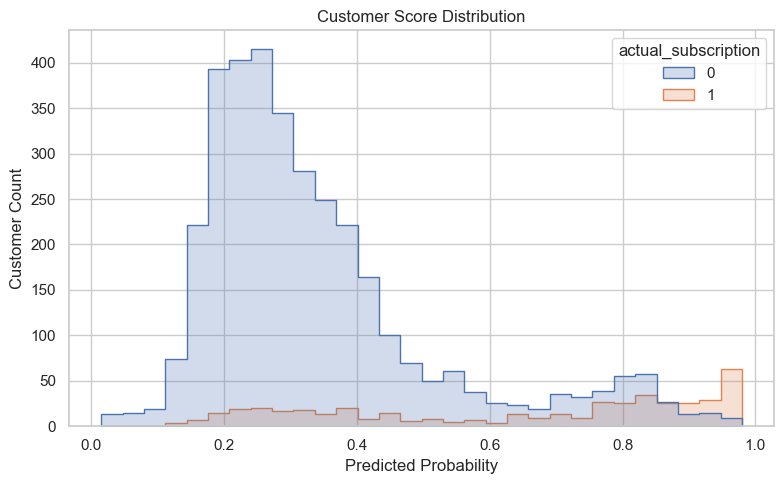

In [12]:
plt.figure(figsize=(8, 5))
sns.histplot(
    data=customer_scores,
    x="predicted_probability",
    hue="actual_subscription",
    bins=30,
    element="step",
)
plt.title("Customer Score Distribution")
plt.xlabel("Predicted Probability")
plt.ylabel("Customer Count")
plt.tight_layout()
plt.show()

## 8. Cumulative Gain View

This shows how many actual subscribers are captured as the campaign contacts more customers ranked by predicted probability.


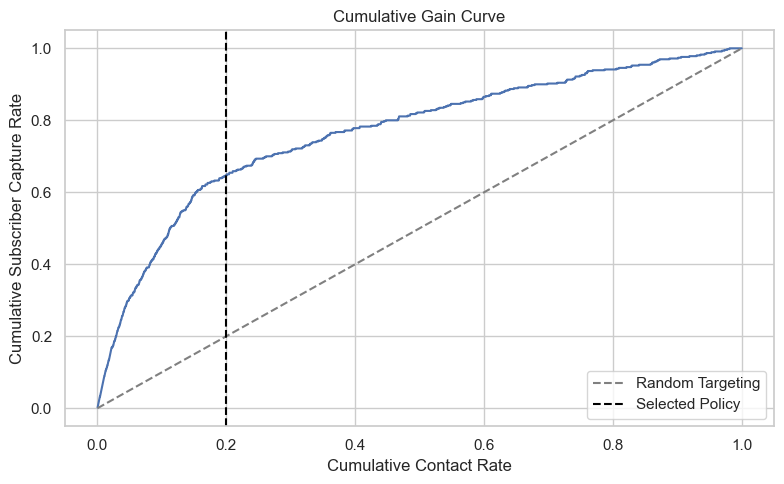

In [13]:
gain_data = customer_scores.sort_values("predicted_probability", ascending=False).reset_index(drop=True)
gain_data["cumulative_customers"] = range(1, len(gain_data) + 1)
gain_data["cumulative_contact_rate"] = gain_data["cumulative_customers"] / len(gain_data)
gain_data["cumulative_subscribers"] = gain_data["actual_subscription"].cumsum()
gain_data["cumulative_capture_rate"] = gain_data["cumulative_subscribers"] / gain_data["actual_subscription"].sum()

plt.figure(figsize=(8, 5))
sns.lineplot(data=gain_data, x="cumulative_contact_rate", y="cumulative_capture_rate")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Targeting")
plt.axvline(selected_contact_rate, linestyle="--", color="black", label="Selected Policy")
plt.title("Cumulative Gain Curve")
plt.xlabel("Cumulative Contact Rate")
plt.ylabel("Cumulative Subscriber Capture Rate")
plt.legend()
plt.tight_layout()
plt.show()

**Interpretation:**


The cumulative gain chart shows that the model captures subscribers much faster than random targeting. The selected top 20% line captures **64.35%** of subscribers, while random targeting would capture only about **20%** at the same contact rate.